## Project 3: Name Gender Classifier

Brandon Chung 4/05/2026

### Instructions

Using any of the three classifiers described in chapter 6 of Natural Language Processing with Python, and any features you can think of, build the best name gender classifier you can. Begin by splitting the Names Corpus into three subsets: 500 words for the test set, 500 words for the dev-test set, and the remaining 6900 words for the training set. Then, starting with the example name gender classifier, make incremental improvements. Use the dev-test set to check your progress. Once you are satisfied with your classifier, check its final performance on the test set. How does the performance on the test set compare to the performance on the dev-test set? Is this what you'd expect?

Source: Natural Language Processing with Python, exercise 6.10.2.

### Loading and Inspecting Data

In [1]:
import nltk
from nltk.corpus import names
import pandas as pd

male_names = names.words('male.txt')
female_names = names.words('female.txt')

df = pd.DataFrame({
    'name': male_names + female_names,
    'gender': ['male'] * len(male_names) + ['female'] * len(female_names)
})

df.head()


,name,gender
0,Aamir,male
1,Aaron,male
2,Abbey,male
3,Abbie,male
4,Abbot,male


In [2]:
# Gender distribution in names dataset
df.gender.value_counts()


gender
female    5001
male      2943
Name: count, dtype: int64

In [3]:
# Name length distribution
df['length'] = df['name'].apply(len)

df.groupby('gender')['length'].describe()


,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
female,5001.0,6.113777,1.555266,2.0,5.0,6.0,7.0,15.0
male,2943.0,5.895345,1.577563,2.0,5.0,6.0,7.0,15.0


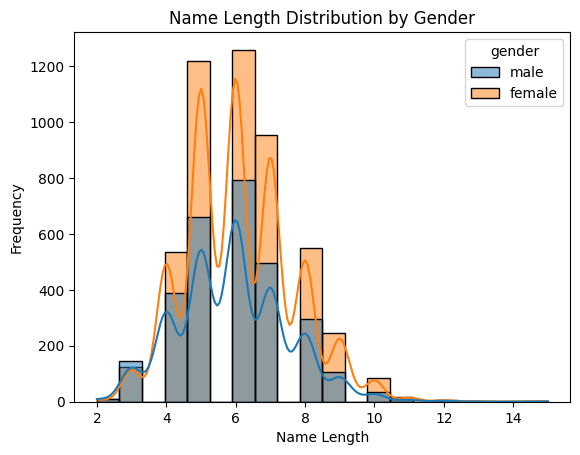

In [4]:
# Visualizing name length distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x='length', hue='gender', bins=20, kde=True)
plt.title('Name Length Distribution by Gender')
plt.xlabel('Name Length')
plt.ylabel('Frequency')
plt.show()

In [5]:
# Last letter distribution
df['last_letter'] = df['name'].str[-1].str.lower()

df = df[df['last_letter'].str.isalpha()] # Filter out names that don't end with a letter

pivot = (
    df.pivot_table(
        index='last_letter',
        columns='gender',
        values='name',
        aggfunc='count',
        fill_value=0
    )
    .apply(lambda x: x / x.sum(), axis=0)
    .sort_index()
)

pivot.head(15)



gender,female,male
last_letter,,
a,0.3546,0.009854
b,0.0018,0.007136
c,0.0000,0.008495
d,0.0078,0.077472
e,0.2864,0.159021
f,0.0004,0.008495
g,0.0020,0.010873
h,0.0210,0.031600
i,0.0634,0.016989


In [6]:
# First letter distribution
df['first_letter'] = df['name'].str[0].str.lower()

pivot = (
    df.pivot_table(
        index='first_letter',
        columns='gender',
        values='name',
        aggfunc='count',
        fill_value=0
    )
    .apply(lambda x: x / x.sum(), axis=0)
    .sort_index()
)

pivot.head(15)


gender,female,male
first_letter,,
a,0.0886,0.072375
b,0.0492,0.058784
c,0.0938,0.056405
d,0.0616,0.049609
e,0.0502,0.040435
f,0.0288,0.029562
g,0.0424,0.053007
h,0.0248,0.055386
i,0.0166,0.015291


<Figure size 1200x600 with 0 Axes>

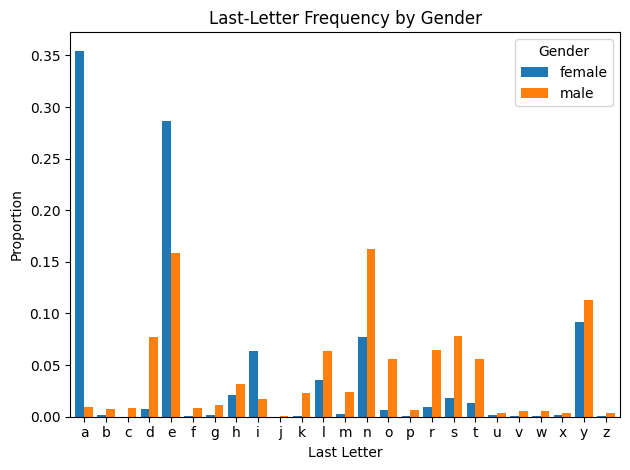

In [7]:
last_letter_freq = (
    df.pivot_table(
        index='last_letter',
        columns='gender',
        values='name',
        aggfunc='count',
        fill_value=0
    )
    .apply(lambda x: x / x.sum(), axis=0)
    .sort_index()
)

# Plot
plt.figure(figsize=(12,6))
last_letter_freq.plot(kind='bar', width=0.8)
plt.title("Last-Letter Frequency by Gender")
plt.xlabel("Last Letter")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

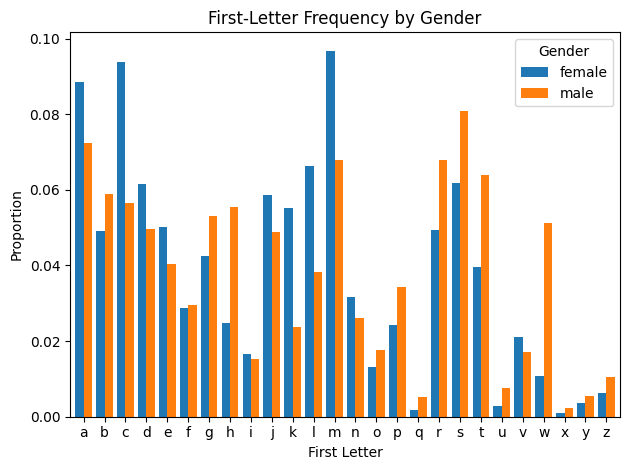

In [8]:
first_letter_freq = (
    df.pivot_table(
        index='first_letter',
        columns='gender',
        values='name',
        aggfunc='count',
        fill_value=0
    )
    .apply(lambda x: x / x.sum(), axis=0)
    .sort_index()
)

# Plot
plt.figure(figsize=(12,6))
first_letter_freq.plot(kind='bar', width=0.8)
plt.title("First-Letter Frequency by Gender")
plt.xlabel("First Letter")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()


In [9]:
# Consonant vs vowel counts

vowels = set("aeiou")

df['vowel_count'] = df['name'].apply(lambda x: sum(c in vowels for c in x.lower()))
df['consonant_count'] = df['name'].apply(lambda x: sum(c.isalpha() and c not in vowels for c in x.lower()))

df.groupby('gender')[['vowel_count','consonant_count']].mean()


,vowel_count,consonant_count
gender,,
female,2.649800,3.458400
male,2.192321,3.699626


Through our EDA we found that the names dataset contains more female names than male names. 5,000 to almost 3,000. Additionally name length (number of letters in a name) seems to be equal for males and females where the standard deviation of the length distribution only differs by 0.02. When comparing first letter and last letter frequency, last letter frequency seems to be more telling - certain last letters of names contain greater proportions of one gender versus the other, especially names ending with 'a'.  

### Setting up Data Splits

In [10]:
import random

labeled_names = list(df[['name', 'gender']].itertuples(index=False, name=None))

random.shuffle(labeled_names)

test_names = labeled_names[:500]
devtest_names = labeled_names[500:1000]
train_names = labeled_names[1000:]

len(train_names), len(devtest_names), len(test_names)


(6943, 500, 500)

### Baseline Example Name Gender Classifier

I am starting with Natural Language Processing with Python's example classifier with using the last letter of the name. From this baseline I will attempt to improve the classifier, continuing with Naive Bayes, but with other features.

In [14]:
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy

def gender_features_baseline(name):
    return {'last_letter': name[-1].lower()}

def apply_features(feature_func, dataset):
    return [(feature_func(name), gender) for (name, gender) in dataset]

train_set_basic = apply_features(gender_features_baseline, train_names)
devtest_set_basic = apply_features(gender_features_baseline, devtest_names)

classifier_basic = NaiveBayesClassifier.train(train_set_basic)

print("Dev-test accuracy (baseline):", accuracy(classifier_basic, devtest_set_basic))


Dev-test accuracy (baseline): 0.766


In [12]:
classifier_basic.show_most_informative_features(10)

Most Informative Features
             last_letter = 'k'              male : female =     40.4 : 1.0
             last_letter = 'a'            female : male   =     34.5 : 1.0
             last_letter = 'f'              male : female =     15.3 : 1.0
             last_letter = 'p'              male : female =     12.6 : 1.0
             last_letter = 'v'              male : female =      9.8 : 1.0
             last_letter = 'd'              male : female =      9.2 : 1.0
             last_letter = 'o'              male : female =      8.5 : 1.0
             last_letter = 'm'              male : female =      7.9 : 1.0
             last_letter = 'r'              male : female =      6.7 : 1.0
             last_letter = 'w'              male : female =      6.2 : 1.0


### Classifier 1 
Classifier with last_letter, first_letter, length, and if the word ends with a vowel

In [15]:
def gender_features(name):
    name = name.lower()
    return {
        'last_letter': name[-1],
        'first_letter': name[0],
        'length': len(name),
        'ends_with_vowel': name[-1] in 'aeiou'
    }

train_set = apply_features(gender_features, train_names)
devtest_set = apply_features(gender_features, devtest_names)

classifier = NaiveBayesClassifier.train(train_set)

print("Dev-test accuracy:", accuracy(classifier, devtest_set))


Dev-test accuracy: 0.766


Our first classifier returned an accuracy which is the same as than the baseline classifier with only the last letter. This tells us that the other features that were added have weak signal and increase noise. From our EDA we knew that name length may not be greatly indicative of gender, so removing that feature going forward. The ends with vowel feature may also be redundent because the last letter feature captures this information.

### Classifier 2
Classifier with last_letter, first_letter, vowel_count and consonant_count

In [16]:
def gender_features_counts(name):
    name = name.lower()
    vowels = set("aeiou")
    vowel_count = sum(c in vowels for c in name)
    consonant_count = sum(c.isalpha() and c not in vowels for c in name)

    return {
        'last_letter': name[-1],
        'first_letter': name[0],
        'vowel_count': vowel_count,
        'consonant_count': consonant_count
    }

train_set_cnt = apply_features(gender_features_counts, train_names)
devtest_set_cnt = apply_features(gender_features_counts, devtest_names)

classifier_cnt = NaiveBayesClassifier.train(train_set_cnt)

print("Dev-test accuracy:", accuracy(classifier_cnt, devtest_set_cnt))


Dev-test accuracy: 0.794


From our EDA vowel and constant counts differed with each gender names, and including these features improved performance, however only be a slight amount. 

### Classifier 3
Classifier with first two letters, last two letters, vowel count, and consonant count

In [17]:
def gender_features_prefix_suffix_counts(name):
    name = name.lower()
    vowels = set("aeiou")
    
    vowel_count = sum(c in vowels for c in name)
    consonant_count = sum(c.isalpha() and c not in vowels for c in name)
    
    return {
        'last_two': name[-2:],
        'first_two': name[:2],
        'vowel_count': vowel_count,
        'consonant_count': consonant_count
    }

train_set_psc = apply_features(gender_features_prefix_suffix_counts, train_names)
devtest_set_psc = apply_features(gender_features_prefix_suffix_counts, devtest_names)

classifier_psc = NaiveBayesClassifier.train(train_set_psc)

print("Dev-test accuracy:", accuracy(classifier_psc, devtest_set_psc))



Dev-test accuracy: 0.822


### Classifier 4
Classifier with only last two letters for comparison with classifier 3

In [18]:
# Classifier with only last two letters

def gender_features_last_two(name):
    return {'last_two': name[-2:].lower()}

train_set_last_two = apply_features(gender_features_last_two, train_names)
devtest_set_last_two = apply_features(gender_features_last_two, devtest_names)
classifier_last_two = NaiveBayesClassifier.train(train_set_last_two)

print("Dev-test accuracy (last two letters):", accuracy(classifier_last_two, devtest_set_last_two))

Dev-test accuracy (last two letters): 0.79


Classifier 3, our Naive Bayes classification model with first two letters, last two letters, vowel count, and consonant count generated the greatest accuracy out of my models. Classifier 3 also performed better in accuracy compared to a classifier with only the last two letters, indicating that the additional features contiributed to the accuracy meaningfully. 

### Conclusion and Evaluation of Classifier 3 on test set

In [17]:
# Testing classifier 3 on test set 

test_set_psc = apply_features(gender_features_prefix_suffix_counts, test_names)
print("Test accuracy (prefix/suffix + counts):", accuracy(classifier_psc, test_set_psc))

Test accuracy (prefix/suffix + counts): 0.78


Overall classifier 3 performed the best out of the trained classifiers. Incrementally improving from the baseline example proved difficult in the beginning due to the strong gender relationship that the last letter of the name holds. However, our findings were generally in-line with what the exploratory analysis showed. Length of the name and if the name ended with a vowel proved to be weak indicators, and the last two letters of the name proved to be the strongest feature. Our final model, classifier 3 used the last two letters and was bolstered by the first two letters, along with vowel count and constonant count. 

The small drop in the classifier accuracy from 0.822 in the dev-test to 0.79 in the test set is expected as I was guaging model performance on accuracy based on the dev-test set. Because the model's performance on the dev-test set influenced my choices the model performs slightly better on it than the test which was held out until final testing.  

Video presentation: https://youtu.be/gb8UsfGDfRs